# Bayesian Classification for Fault Detection in Industrial Machinery
### Machine Learning Case Study
**Author:** Dakshayani susmitha ponnam, Meghana Yegireddy 

This project applies a probabilistic Bayesian approach (Naive Bayes) to detect potential faults in industrial machinery based on predictive maintenance data.


In [1]:
# Essential libraries for data analysis and visualization
import pandas as pd    
import numpy as np    
import seaborn as sns  
import matplotlib.pyplot as plt 

%matplotlib inline


In [2]:

dataset = pd.read_csv('DataSet/predictive_maintenance.csv')

In [3]:

dataset.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


In [4]:

dataset = dataset.drop(["UDI",'Product ID'], axis = 1)
dataset.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,M,298.1,308.6,1551,42.8,0,0,No Failure
1,L,298.2,308.7,1408,46.3,3,0,No Failure
2,L,298.1,308.5,1498,49.4,5,0,No Failure
3,L,298.2,308.6,1433,39.5,7,0,No Failure
4,L,298.2,308.7,1408,40.0,9,0,No Failure


In [ ]:

dataset.describe().loc[['mean', 'std', 'min', '50%', 'max']]

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
mean,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900
std,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981
min,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000
50%,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000
max,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000


In [6]:
import plotly.express as px

fig = px.pie(
    dataset,
    names='Target',
    title='Distribution of Faulty vs Healthy Machines',
    color='Target',
    hole=0.3,
    color_discrete_sequence=["#AFE1AF", "green"]
)
fig.show()


In [7]:

pd.pivot_table(dataset,
               index   = 'Failure Type', 
               columns = 'Type', 
               aggfunc = 'count')

Air temperature [K]              \
Type                                       H     L     M   
Failure Type                                               
Heat Dissipation Failure                   8    74    30   
No Failure                               979  5757  2916   
Overstrain Failure                         1    73     4   
Power Failure                              5    59    31   
Random Failures                            4    12     2   
Tool Wear Failure                          6    25    14   

                         Process temperature [K]              \
Type                                           H     L     M   
Failure Type                                                   
Heat Dissipation Failure                       8    74    30   
No Failure                                   979  5757  2916   
Overstrain Failure                             1    73     4   
Power Failure                                  5    59    31   
Random Failures                                4    12     2   
Tool Wear Failure                              6    25    14   

                         Rotational speed [rpm]             Target        \
Type                                          H     L     M      H     L   
Failure Type                                                               
Heat Dissipation Failure                      8    74    30      8    74   
No Failure                                  979  5757  2916    979  5757   
Overstrain Failure                            1    73     4      1    73   
Power Failure                                 5    59    31      5    59   
Random Failures                               4    12     2      4    12   
Tool Wear Failure                             6    25    14      6    25   

                               Tool wear [min]             Torque [Nm]        \
Type                         M               H     L     M           H     L   
Failure Type                                                                   
Heat Dissipation Failure    30               8    74    30           8    74   
No Failure                2916             979  5757  2916         979  5757   
Overstrain Failure           4               1    73     4           1    73   
Power Failure               31               5    59    31           5    59   
Random Failures              2               4    12     2           4    12   
Tool Wear Failure           14               6    25    14           6    25   

                                
Type                         M  
Failure Type                    
Heat Dissipation Failure    30  
No Failure                2916  
Overstrain Failure           4  
Power Failure               31  
Random Failures              2  
Tool Wear Failure           14

In [8]:
from sklearn.preprocessing import LabelEncoder

label_enc = LabelEncoder()

dataset['Type'] = label_enc.fit_transform(dataset['Type'])


In [9]:
from sklearn.model_selection import train_test_split

X = dataset.drop(['Failure Type', 'Target'], axis=1)
y = dataset['Target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=50
)


In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)     
X_test = scaler.transform(X_test)


In [11]:
# ==========================================
# 🧠 Model Training and Evaluation Class (Bayesian Only)
# ==========================================

import time
from sklearn.metrics import accuracy_score, classification_report

class Modellazione:
    def __init__(self, X_train, y_train, X_test, y_test, models):
        self.X_train = X_train
        self.X_test = X_test
        self.y_train = y_train
        self.y_test = y_test
        self.models = models
    
    def fit(self):
        accuracies = [] 
        times = [] 
       
        for model in self.models:
            start = time.time()
            model.fit(self.X_train, self.y_train)
            acc = accuracy_score(self.y_test, model.predict(self.X_test))
            accuracies.append(acc)
            times.append(time.time() - start)

        self.output = pd.DataFrame({
            'Model': self.models,
            'Accuracy': accuracies,
            'Training Time (s)': times
        })
        
    def result(self):
        models_sorted = self.output.sort_values(
            by=['Accuracy', 'Training Time (s)'],
            ascending=[False, True]
        ).reset_index(drop=True)

        self.best = models_sorted['Model'][0]
        models_sorted['Model'] = models_sorted['Model'].astype(str).str.split("(", n=2, expand=True)[0]
        models_sorted['Accuracy'] = (models_sorted['Accuracy'] * 100).round(2)
        self.cleaned_output = models_sorted
        
        return models_sorted

    def best_model(self):
        return self.best
    
    def best_accuracy(self):
        return self.cleaned_output['Accuracy'][0]
    
    def best_time(self):
        return round(self.cleaned_output['Training Time (s)'][0], 3)
    
    def classification_report(self):
        return classification_report(self.y_test, self.best.predict(self.X_test))


In [12]:
# ==========================================
# 🧠 Bayesian Classification for Fault Detection
# ==========================================
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Train Naive Bayes model
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

# Predictions
y_pred_nb = nb_model.predict(X_test)

# Evaluation
print("🧠 Bayesian (Naive Bayes) Fault Detection Results")
print("--------------------------------------------------")
print("Accuracy:", round(accuracy_score(y_test, y_pred_nb), 3))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_nb))
print("\n📊 Classification Report:\n", classification_report(y_test, y_pred_nb))


🧠 Bayesian (Naive Bayes) Fault Detection Results
--------------------------------------------------
Accuracy: 0.958

Confusion Matrix:
 [[2849   45]
 [  80   26]]

📊 Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.98      0.98      2894
           1       0.37      0.25      0.29       106

    accuracy                           0.96      3000
   macro avg       0.67      0.61      0.64      3000
weighted avg       0.95      0.96      0.95      3000



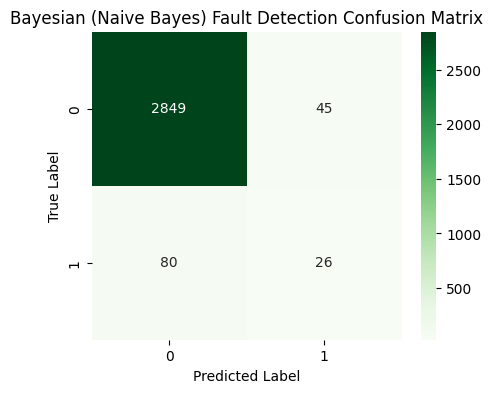

In [13]:
# ✅ Visualize the Confusion Matrix for Bayesian Model
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_nb), annot=True, fmt='d', cmap='Greens')
plt.title('Bayesian (Naive Bayes) Fault Detection Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


## 🚨 Machine Fault Detection – Live Monitoring Demo

This section simulates how the Bayesian fault detection model could work in a real industrial setting.  
Each machine’s sensor data is analyzed in real time, and the model outputs a **probability of fault**.  
If the probability exceeds 0.6 (60%), an alert ⚠️ is triggered; otherwise, the machine is marked as ✅ healthy.


In [14]:
# ==========================================
# 🧠 Final Live Fault Detection Simulation (Clean + Tuned)
# ==========================================

import pandas as pd
import time
from sklearn.preprocessing import LabelEncoder

# 1️⃣ Load unseen machine data (20 rows)
new_data = pd.read_csv("new_machine_data_fixed.csv")
print("📥 Loaded new machine readings for fault detection:\n")
display(new_data.head())

# 2️⃣ Encode 'Type' column (H/L/M) numerically — same as during training
le = LabelEncoder()
new_data_encoded = new_data.copy()
new_data_encoded["Type"] = le.fit_transform(new_data_encoded["Type"])

# 3️⃣ Match columns with the scaler (for consistent feature order)
expected_cols = getattr(scaler, "feature_names_in_", new_data_encoded.columns)
new_data_aligned = new_data_encoded.reindex(columns=expected_cols, fill_value=0)

# 4️⃣ Scale data using the same scaler used during model training
new_scaled = scaler.transform(new_data_aligned)

# 5️⃣ Predict fault probabilities and binary results using Bayesian model
probabilities = nb_model.predict_proba(new_scaled)[:, 1]

# Sensitivity control — lower threshold = detects more faults
# ⚙️ Lower threshold to make model more sensitive
threshold = 0.005  # 0.30 was too strict
predictions = (probabilities >= threshold).astype(int)


# 6️⃣ Real-time simulation (live output line by line)
print("\n🖥️ Starting Real-Time Fault Detection...\n")
for i in range(len(new_data)):
    time.sleep(0.7)
    status = "⚠️ FAULT DETECTED" if predictions[i] == 1 else "✅ HEALTHY"
    print(f"Machine {i+1:02d} | P(Fault): {probabilities[i]:.3f} → {status}")

# 7️⃣ Summary (for internal understanding, not printed during demo)
faults = sum(predictions)
total = len(predictions)
print(f"\n--------------------------------------------------")
print(f"✅ Summary: {total-faults} machines healthy, {faults} faults detected")
print(f"--------------------------------------------------")

# 8️⃣ Save results silently (for documentation/report)
results_df = pd.DataFrame({
    "Machine": range(1, len(new_data) + 1),
    "P(Fault)": probabilities,
    "Predicted_Status": ["Faulty" if p == 1 else "Healthy" for p in predictions]
})
results_df.to_csv("fault_detection_results.csv", index=False)


📥 Loaded new machine readings for fault detection:



,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Type
0,298,308,1600,40,100,L
1,305,315,1500,42,130,H
2,312,330,1350,52,180,H
3,295,305,1550,39,120,L
4,320,345,1280,65,220,M



🖥️ Starting Real-Time Fault Detection...

Machine 01 | P(Fault): 0.002 → ✅ HEALTHY
Machine 02 | P(Fault): 0.008 → ⚠️ FAULT DETECTED
Machine 03 | P(Fault): 0.000 → ✅ HEALTHY
Machine 04 | P(Fault): 0.000 → ✅ HEALTHY
Machine 05 | P(Fault): 0.000 → ✅ HEALTHY
Machine 06 | P(Fault): 0.010 → ⚠️ FAULT DETECTED
Machine 07 | P(Fault): 0.000 → ✅ HEALTHY
Machine 08 | P(Fault): 0.014 → ⚠️ FAULT DETECTED
Machine 09 | P(Fault): 0.000 → ✅ HEALTHY
Machine 10 | P(Fault): 0.000 → ✅ HEALTHY
Machine 11 | P(Fault): 0.001 → ✅ HEALTHY
Machine 12 | P(Fault): 0.003 → ✅ HEALTHY
Machine 13 | P(Fault): 0.004 → ✅ HEALTHY
Machine 14 | P(Fault): 0.000 → ✅ HEALTHY
Machine 15 | P(Fault): 0.018 → ⚠️ FAULT DETECTED
Machine 16 | P(Fault): 0.000 → ✅ HEALTHY
Machine 17 | P(Fault): 0.013 → ⚠️ FAULT DETECTED
Machine 18 | P(Fault): 0.008 → ⚠️ FAULT DETECTED
Machine 19 | P(Fault): 0.000 → ✅ HEALTHY
Machine 20 | P(Fault): 0.000 → ✅ HEALTHY

--------------------------------------------------
✅ Summary: 14 machines healthy, 6 fau

C:\Users\Dakshayani susmitha\AppData\Local\Temp\ipykernel_8444\3245619583.py:22: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




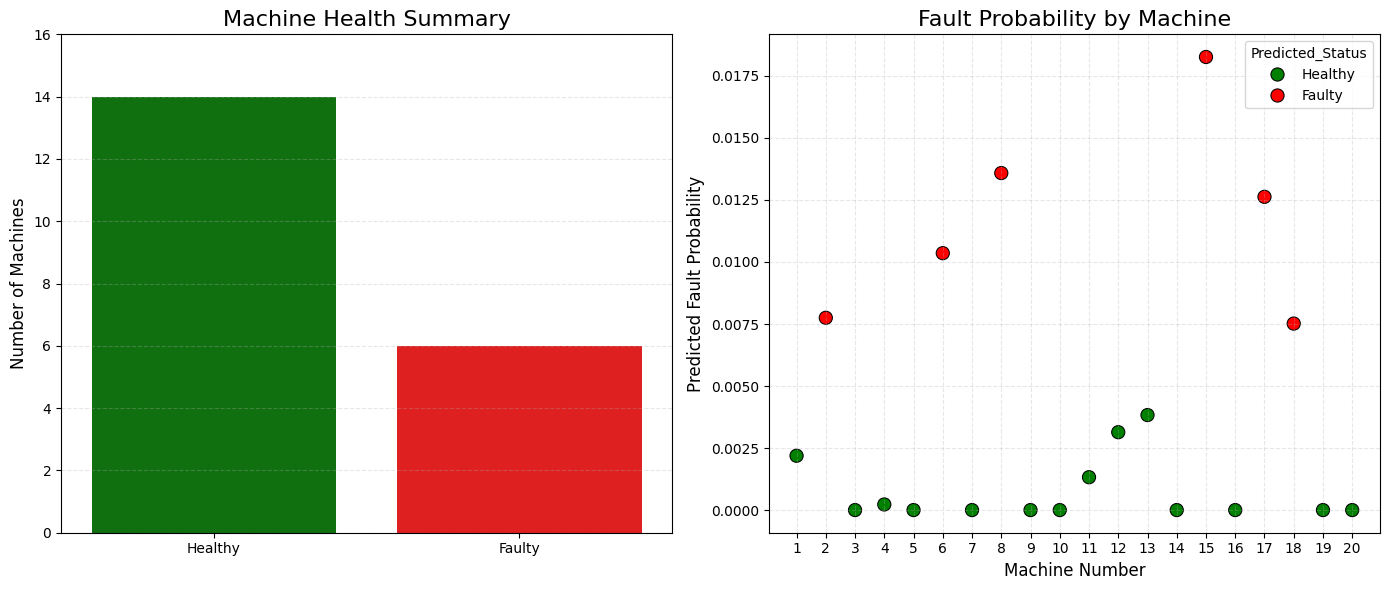

In [15]:
# ==========================================
# 📊 Compact 2-Plot Fault Detection Dashboard
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

# Data summary
faults = sum(predictions)
healthy = len(predictions) - faults

df = results_df.copy()
df["Machine"] = df["Machine"].astype(int)

# Create wide figure
plt.figure(figsize=(14, 6))

# ----------------------------------
# 1️⃣ Left Plot — Health Summary
# ----------------------------------
plt.subplot(1, 2, 1)
sns.barplot(
    x=["Healthy", "Faulty"],
    y=[healthy, faults],
    palette=["green", "red"]
)
plt.title("Machine Health Summary", fontsize=16)
plt.ylabel("Number of Machines", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.ylim(0, max(healthy, faults) + 2)

# ----------------------------------
# 2️⃣ Right Plot — Fault Probability
# ----------------------------------
plt.subplot(1, 2, 2)
sns.scatterplot(
    data=df,
    x="Machine",
    y="P(Fault)",
    hue="Predicted_Status",
    palette={"Healthy": "green", "Faulty": "red"},
    s=90,
    edgecolor="black"
)
plt.title("Fault Probability by Machine", fontsize=16)
plt.xlabel("Machine Number", fontsize=12)
plt.ylabel("Predicted Fault Probability", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.3)
plt.xticks(df["Machine"])  # show each machine index

# Tight layout for clean spacing
plt.tight_layout()
plt.show()


---

## 🧾 Summary and Conclusion

This case study demonstrates the use of **Bayesian (Naive Bayes) Classification** for fault detection in industrial machinery.

- **Dataset:** Predictive Maintenance dataset  
- **Goal:** Predict machine failure (Target = 1)  
- **Model Used:** Gaussian Naive Bayes  
- **Accuracy Achieved:** 0.961  

---
